In [93]:
## import dependencies
import os
import re
import sys
import json
import h5py
import numpy as np
import matplotlib.pyplot as plt

## Add the path to the DiscEvolution directory
sys.path.append('/Users/ben/Downloads/Planet Formation/Code/DiscEvolution Core Accretion')

## import DiscEvolution modules
from DiscEvolution.constants import *
from DiscEvolution.grid import Grid
from DiscEvolution.star import SimpleStar
from DiscEvolution.eos import IrradiatedEOS, LocallyIsothermalEOS, SimpleDiscEOS
from DiscEvolution.disc import *
from DiscEvolution.viscous_evolution import ViscousEvolution, ViscousEvolutionFV, LBP_Solution, HybridWindModel, TaboneSolution
from DiscEvolution.disc import AccretionDisc
from DiscEvolution.dust import *
from DiscEvolution.dust import PlanetesimalFormation
from DiscEvolution.planet_formation import *
from DiscEvolution.diffusion import TracerDiffusion
from DiscEvolution.opacity import Tazzari2016
from DiscEvolution.chemistry import *

In [94]:
## Method to read data from an HDF5 dataset or group

def read_hdf5_array(obj):
    """
    Read data from either an HDF5 dataset or an HDF5 group.
    """

    ## Normal case (the data are stored as one HDF5 dataset)
    if isinstance(obj, h5py.Dataset):
        return np.array(obj)

    ## Ragged case (the data are stored as a group)
    elif isinstance(obj, h5py.Group):
        values = []

        for key in sorted(obj.keys(), key = int):
            values.append(np.array(obj[key]))

        return values

    ## Raise an error if an unexpected HDF5 object is encountered
    else:
        raise TypeError(f"Unexpected HDF5 object type: {type(obj)}")

## Method to load data from an HDF5 file, together with the config used to produce it

def load_data(data_dir, config_dir):
    """
    Load a disc evolution output file (HDF5 only).

    Parameters:
        data_dir: Path to the HDF5 output file.
        config_dir: Path to the JSON config file used for the run.

    Returns:
        data: Dictionary containing the simulation output.
        config: Dictionary containing the simulation config file.
    """

    data = {}

    ## Load the configuration file

    with open(config_dir, "r") as f:
        config = json.load(f)

    ## Open the HDF5 file in read-only mode
    with h5py.File(data_dir, "r") as f:

        ## -----------------------
        ## General simulation data
        ## -----------------------

        general_keys = [
            "R",
            "t",
            "disk_Mdot_star",
            "disk_Mass",
            "Tc",
            "Sigc"]

        for key in general_keys:
            ## Only load the quantity if it exists in the file
            if key in f:
                data[key] = np.array(f[key])

        ## ---------------
        ## Alpha viscosity
        ## ---------------

        if "alpha_SS" in f.attrs:
            data["alpha_SS"] = float(f.attrs["alpha_SS"])

        elif "alpha_SS" in f:
            data["alpha_SS"] = float(f["alpha_SS"][()])

        if config["winds"]["on"]:
            data["psi"] = config["winds"]["psi_DW"]

        ## -------------
        ## Disk profiles
        ## -------------

        disk_keys = [
            "T",
            "time_snap",
            "Sigma_G",
            "Sigma_dust",
            "Sigma_pebbles",
            "Sigma_planetesimals",
            "Vdrift_grains",
            "Vdrift_pebbles",
            "St_grains",
            "St_pebbles",
            "St_planetesimals",
            "e_planetesimals",
            "i_planetesimals",
            "de2_dt",
            "di2_dt",
            "de2_dt_drag",
            "di2_dt_drag",
            "de2_dt_VS_embryo",
            "di2_dt_VS_embryo",
            "de2_dt_VS_pltsml",
            "di2_dt_VS_pltsml",
            "de2_dt_DF",
            "di2_dt_DF"]

        for key in disk_keys:
            ## Only load the quantity if it exists in the file
            if key in f:
                data[key] = read_hdf5_array(f[key])

        ## -----------
        ## Planet data
        ## -----------

        if config["planets"]["include_planets"]:
            planet_keys = [
                "Mcs",
                "Mes",
                "Rp",
                "disk_Mdot_p",
                "Mdot_planetesimal",
                "Mdot_pebble_core",
                "Mdot_pebble_env",
                "Mdot_migration",
                "Mdot_gas",
                "M_iso_planetesimal",
                "M_iso_pebble",
                "X_cores",
                "X_envs"]

            for key in planet_keys:
                if key in f:
                    data[key] = read_hdf5_array(f[key])

    return data, config

In [95]:
## Load data and config file

data_dir = "/Users/ben/Downloads/Planet Formation/DiscEvolution Simulations/Output/20260811_1734_psi10_Mdot1.0e-08_M0.1_Rd50.h5"
config_dir = "/Users/ben/Downloads/Planet Formation/DiscEvolution Simulations/Config/20260810_balogh2026_SI.json"
data, config = load_data(data_dir, config_dir)

data_dir_PA = "/Users/ben/Downloads/Planet Formation/DiscEvolution Simulations/Output/20260812_0428_psi10_Mdot1.0e-08_M0.1_Rd50.h5"
config_dir_PA = "/Users/ben/Downloads/Planet Formation/DiscEvolution Simulations/Config/20260810_full_accretion.json"
data_PA, config_PA = load_data(data_dir_PA, config_dir_PA)

In [96]:
## Figure output

config_name = os.path.splitext(os.path.basename(config_dir))[0]
figure_dir = f"/Users/ben/Downloads/Planet Formation/DiscEvolution Plots/"

if not(os.path.exists(figure_dir)):
        os.makedirs(figure_dir)

save_figures = True

In [97]:
## Extract data for plotting

R_imp = config["planets"]["Rp"]
Rp = data["Rp"]
Mcs = data["Mcs"]
Mes = data["Mes"]

R_imp_PA = config_PA["planets"]["Rp"]
Rp_PA = data_PA["Rp"]
Mcs_PA = data_PA["Mcs"]
Mes_PA = data_PA["Mes"]

t = data["t"]
t_PA = data_PA["t"]
t_interval = config["simulation"]["t_interval"]

In [98]:
## Matplotlib colors

n_times = len(t_interval)

color_blues = plt.cm.Blues(np.linspace(1, 0.4, n_times))
color_greys = plt.cm.Greys(np.linspace(1, 0.4, n_times))
color_greens = plt.cm.Greens(np.linspace(1, 0.4, n_times))
color_reds = plt.cm.Reds(np.linspace(1, 0.4, n_times))

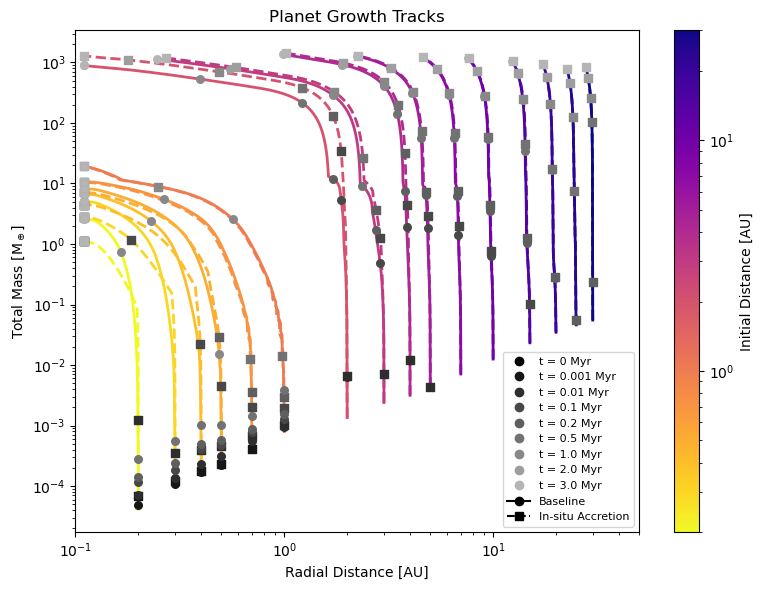

In [99]:
## Plot planet growth tracks, colored by initial radial distance

from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D
from matplotlib.cm import ScalarMappable

n_planets = len(Rp)
n_planets_PA = len(Rp_PA)
n_times = len(t_interval)

fig, ax = plt.subplots(figsize = (8, 6))

cmap = plt.get_cmap('plasma_r')

R0_all = [R_imp[i] for i in range(n_planets)] + [R_imp_PA[i] for i in range(n_planets_PA)]
norm = LogNorm(vmin = min(R0_all), vmax = max(R0_all))

## Baseline growth tracks (solid)

for i in range(n_planets):
    y = Mcs[i] + Mes[i]
    color = cmap(norm(R_imp[i]))

    ax.plot(Rp[i], y, color = color, linestyle = 'solid', linewidth = 2, zorder = 1)

    for j in range(n_times):
        k = np.argmin(np.abs(t / 1e6 - t_interval[j]))

        ax.scatter(Rp[i][k], y[k], color = color_greys[j], marker = 'o', s = 30, zorder = 3)

## Planetesimal accretion growth tracks (dashed)

for i in range(n_planets_PA):
    y_PA = Mcs_PA[i] + Mes_PA[i]
    color = cmap(norm(R_imp_PA[i]))

    ax.plot(Rp_PA[i], y_PA, color = color, linestyle = 'dashed', linewidth = 2, zorder = 1)

    for j in range(n_times):
        k_PA = np.argmin(np.abs(t_PA / 1e6 - t_interval[j]))

        ax.scatter(Rp_PA[i][k_PA], y_PA[k_PA], color = color_greys[j], marker = 's', s = 30, zorder = 2)

ax.set_xlim(1e-1, 1e2 / 2)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Radial Distance [AU]')
ax.set_ylabel(r'Total Mass [M$_\oplus$]')
ax.set_title('Planet Growth Tracks')

sm = ScalarMappable(cmap = cmap, norm = norm)
cbar = fig.colorbar(sm, ax = ax)
cbar.set_label('Initial Distance [AU]')

## Legend entries

time_handles = [
    Line2D([0], [0], color = color_greys[j], marker = 'o', linestyle = 'None', label = f't = {t_interval[j]} Myr')
    for j in range(n_times)]

style_handles = [
    Line2D([0], [0], color = 'black', linestyle = 'solid', marker = 'o', label = 'Baseline'),
    Line2D([0], [0], color = 'black', linestyle = 'dashed', marker = 's', label = 'In-situ Accretion')]

ax.legend(handles = time_handles + style_handles, loc = 'lower right', fontsize = 8)

plt.tight_layout()

if save_figures:
    plt.savefig(f"{figure_dir}growth_tracks_baseline_vs_insitu.png")

plt.show()